In [1]:
# Import necessary libraries 

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import tensorflow 
from tensorflow import keras

from keras import Sequential
from keras.layers import Dense,Input

In [2]:
# Fetched this dataset from kaggle 
# The link is as below : 

https://www.kaggle.com/datasets/rakeshrau/social-network-ads

In [3]:
# I have already this downloaded this dataset and have it in the same folder as this code .

In [4]:
# We will be using three columns only to ease our evaluation
df = pd.read_csv('Social_Network_Ads.csv',usecols=['Age','EstimatedSalary','Purchased'])

In [5]:
df.head() # Skim the head

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
# Also I found that EstimatedSalary was not on the same scale as Age (of course ) so we will normalize them both later
# using StandardScaler

In [7]:
df.shape # We have got 400 rows and three columns

(400, 3)

In [8]:
# Now lets split the dataset and normalize the X set

In [9]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [10]:
X.head() # The Independent variables

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [11]:
y.head() # The output or the dependent variable

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [12]:
scale = StandardScaler() # Instantiate the scaler and store in a variable
scale.fit(X) # Always fit first to avoid data leaks

X_scalled = scale.transform(X)

In [13]:
X_scalled[:5] # The first 5 rows now rescalled

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059]])

In [14]:
# Now let build our neural network

In [15]:
model = Sequential() # Instantiate using Sequential because we are building a sequential model for now
model.add(Input(shape=(X.shape[1],))) # Use this to pass the now of cols, in the dataset 

# Add the layer moving from input to output , and also place the activation function in each 
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [16]:
model.summary() # Call this to look at the summary of the parameters and layers we made 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Now compile the model with the loss function for the model
model.compile(loss='binary_crossentropy',metrics=['accuracy'])

In [18]:
# This was the basic setup for the problem before we apply differnt types of gradient descent on the neural network to learn parameters

### Batch Gradient Descent

In [19]:
# Basically the tweak here is we set the batch size when fitting equal to X.shape[0] because 
# we will be only updating all the paramters once each epoch
# So no_of_updates = epoch

In [20]:
# Also we will be noting down the time differnce for each algorithm to compare later 

In [21]:
start_bgd = time.time() # <-- Note the start 

history = model.fit(  
            X_scalled, # Make sure to pass X_Scalled NOT X !!! 
            y,
            epochs = 10, # I took a small value for demonstration only can use upto 100 or 500 in PC's with dedicated GPU and TPU
            batch_size = X.shape[0], # Also this is the most important
            validation_split = 0.2 # Validation set to validate
            )

end_bgd = time.time() # <-- Note the end

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.2812 - loss: 0.7509 - val_accuracy: 0.6000 - val_loss: 0.6847
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step - accuracy: 0.2812 - loss: 0.7424 - val_accuracy: 0.6875 - val_loss: 0.6850
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.2969 - loss: 0.7363 - val_accuracy: 0.7000 - val_loss: 0.6853
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3187 - loss: 0.7314 - val_accuracy: 0.6875 - val_loss: 0.6855
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3344 - loss: 0.7270 - val_accuracy: 0.7125 - val_loss: 0.6858
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.3562 - loss: 0.7230 - val_accuracy: 0.7000 - val_loss: 0.6860
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.3906 - loss: 0.7193 - val_accuracy: 0.7000 - val_loss: 0.6861
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - accuracy: 0.4187 - loss: 0.7158 - val_accuracy: 0.7125 - val_loss: 0.6863
E

In [22]:
time_bgd = end_bgd - start_bgd

In [23]:
time_bgd 
# Took these much seconds on my laptop ( Depends on the place where this code block was running )
# I ran this on ram and with no gpu so this could be faster

22.202873468399048

In [24]:
# Now we will also plot the loss over time to understand the nature of bgd more

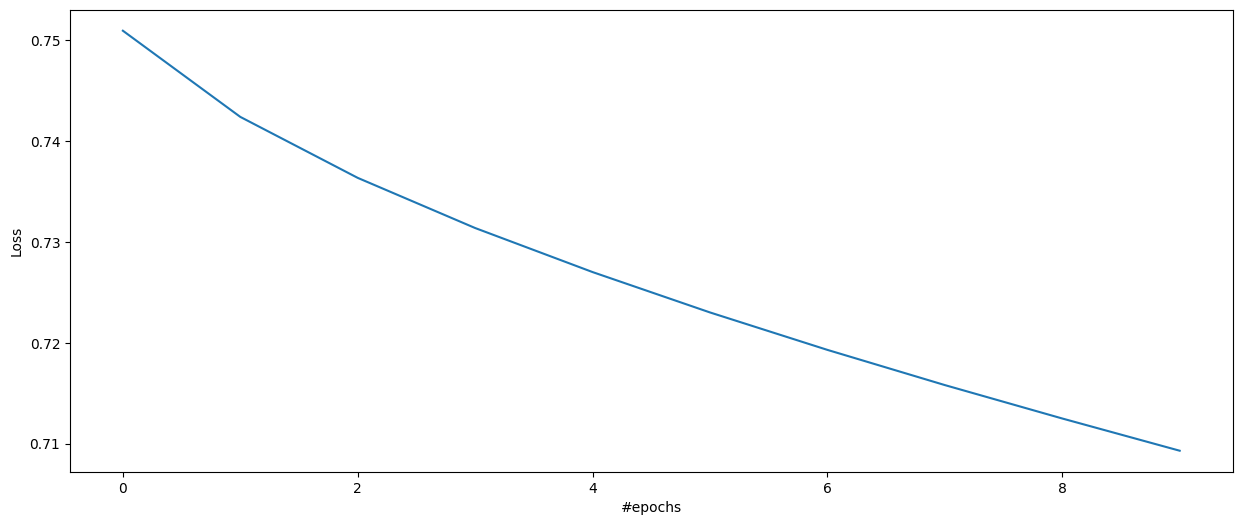

In [25]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss']) # Plots the loss values across epochs
plt.ylabel('Loss')
plt.xlabel('#epochs')
plt.show()

In [26]:
# As expected we got a linear graph as in batch gradient descent the loss is linear decreasing and tends to the precise solution

### Stochastic Gradient Descent 

In [27]:
# Now the tweak here is we set the batch size when fitting equal to 1 because 
# we will updating each row in a single epoch so : 
# So no_of_updates = epoch*X.shape[0]

In [28]:
start_sgd = time.time() # <-- Note the start 

history = model.fit(  
            X_scalled, # Make sure to pass X_Scalled NOT X !!! 
            y,
            epochs = 10, 
            batch_size = 1, # Pass 1 here now
            validation_split = 0.2 # Validation set to validate
            )

end_sgd = time.time() # <-- Note the end

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7406 - loss: 0.5606 - val_accuracy: 0.3625 - val_loss: 0.6824
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7156 - loss: 0.4178 - val_accuracy: 0.3750 - val_loss: 0.6368
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8000 - loss: 0.3629 - val_accuracy: 0.7375 - val_loss: 0.5716
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8656 - loss: 0.3288 - val_accuracy: 0.8125 - val_loss: 0.5065
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8625 - loss: 0.3058 - val_accuracy: 0.9000 - val_loss: 0.4392
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8625 - loss: 0.2856 - val_accuracy: 0.9000 - val_loss: 0.3833
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8656 - loss: 0.2756 - val_accuracy: 0.9125 - val_loss: 0.3516
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8656 - loss: 0.2750 - val_accuracy

In [29]:
time_sgd = end_sgd - start_sgd

In [30]:
time_sgd # As expected took a lot longer than batch gradient descent

41.484619140625

In [31]:
# Now plotting the loss

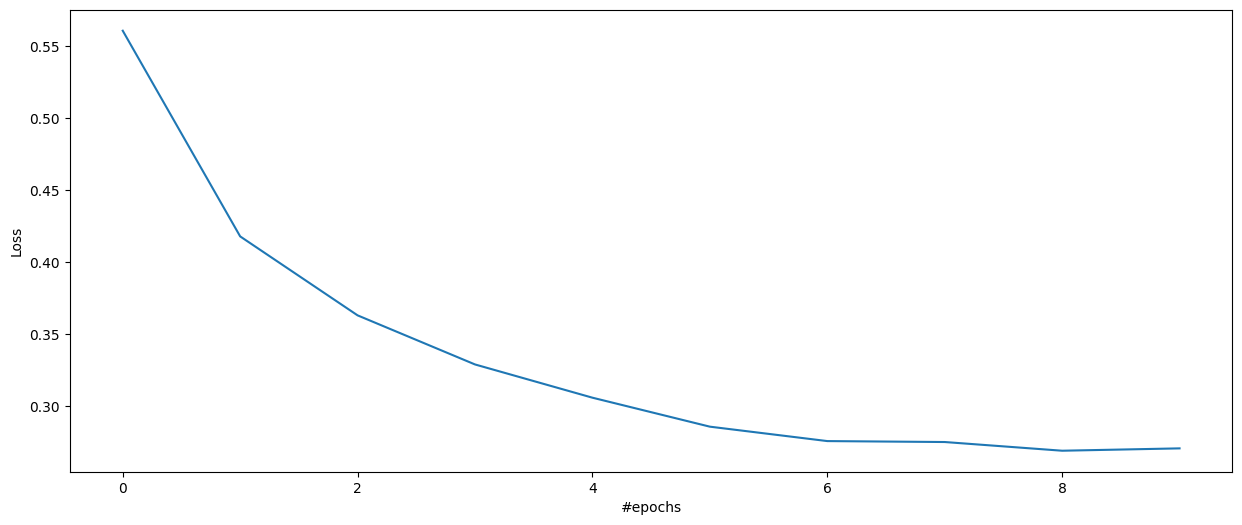

In [32]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss']) 
plt.ylabel('Loss')
plt.xlabel('#epochs')
plt.show()

In [33]:
# As expected a stochastic graph as we take random values and update values in a random manner

### Mini Batch Gradient Descent

In [34]:
# Similar to stochastic but we dont update all the parameters we update according to a batch size 

In [35]:
# Now here we set the batch size when fitting equal to a constant value because 
# we will updating the the constant amount of rows each time in a single epoch so : 
# So no_of_updates = epoch*batch_size

In [ ]:
# For now lets take batch size = k =  64

In [37]:
start_mbgd = time.time() # <-- Note the start 

history = model.fit(  
            X_scalled, 
            y,
            epochs = 10, 
            batch_size = 64, # Pass k here
            validation_split = 0.2 # Validation set to validate
            )

end_mbgd = time.time() # <-- Note the end

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - accuracy: 0.8750 - loss: 0.2668 - val_accuracy: 0.9250 - val_loss: 0.2812
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8750 - loss: 0.2666 - val_accuracy: 0.9250 - val_loss: 0.2808
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.8750 - loss: 0.2664 - val_accuracy: 0.9250 - val_loss: 0.2802
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.8750 - loss: 0.2660 - val_accuracy: 0.9250 - val_loss: 0.2796
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 582ms/step - accuracy: 0.8750 - loss: 0.2657 - val_accuracy: 0.9250 - val_loss: 0.2791
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.8750 - loss: 0.2654 - val_accuracy: 0.9250 - val_loss: 0.2783
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.8750 - loss: 0.2650 - val_accuracy: 0.9250 - val_loss: 0.2776
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.8750 - loss: 0.2644 - val_accuracy: 0.9250 - val_loss: 

In [38]:
time_mbgd = end_mbgd - start_mbgd

In [40]:
time_mbgd # As expected as mini-batch is the best of the both worlds it has a fitting time in between bgd and sgd

14.210333585739136

In [41]:
# Now plotting the loss

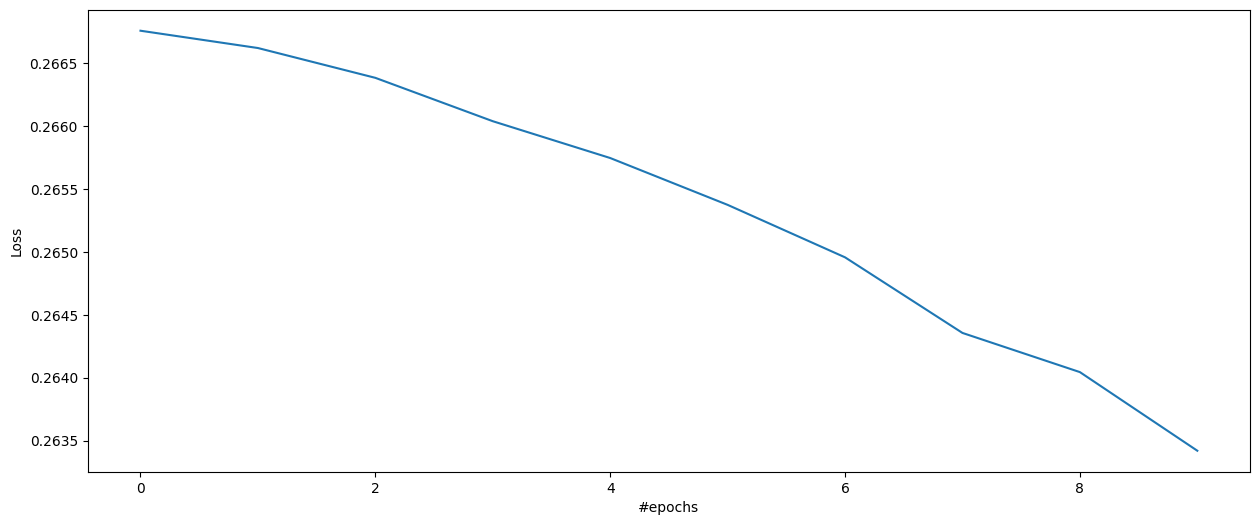

In [42]:
plt.figure(figsize=(15,6))
plt.plot(history.history['loss']) 
plt.ylabel('Loss')
plt.xlabel('#epochs')
plt.show()

In [43]:
# As you can see this looks like batch gradient descent's graph but with some randomness in the descent

In [44]:
# We can later experiment with large number of epochs for each technique to get a denser graph 